<a href="https://colab.research.google.com/github/khupkhaidopmul-stack/lis4693/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import re
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [16]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2019/2019-04-23/tidy_anime.csv"
df = pd.read_csv(url)

df = df.dropna(subset=["synopsis"])
df = df.reset_index(drop=True)

df.head()

,animeID,name,title_english,title_japanese,title_synonyms,type,source,producers,genre,studio,...,scored_by,rank,popularity,members,favorites,synopsis,background,premiered,broadcast,related
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,[],TV,Original,Bandai Visual,Action,Sunrise,...,405664,26,39,795733,43460,"In the year 2071, humanity has colonized sever...",When Cowboy Bebop first aired in spring of 199...,Spring 1998,Saturdays at 01:00 (JST),"{'Adaptation': [{'mal_id': 173, 'type': 'manga..."
1,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,[],TV,Original,Bandai Visual,Adventure,Sunrise,...,405664,26,39,795733,43460,"In the year 2071, humanity has colonized sever...",When Cowboy Bebop first aired in spring of 199...,Spring 1998,Saturdays at 01:00 (JST),"{'Adaptation': [{'mal_id': 173, 'type': 'manga..."
2,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,[],TV,Original,Bandai Visual,Comedy,Sunrise,...,405664,26,39,795733,43460,"In the year 2071, humanity has colonized sever...",When Cowboy Bebop first aired in spring of 199...,Spring 1998,Saturdays at 01:00 (JST),"{'Adaptation': [{'mal_id': 173, 'type': 'manga..."
3,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,[],TV,Original,Bandai Visual,Drama,Sunrise,...,405664,26,39,795733,43460,"In the year 2071, humanity has colonized sever...",When Cowboy Bebop first aired in spring of 199...,Spring 1998,Saturdays at 01:00 (JST),"{'Adaptation': [{'mal_id': 173, 'type': 'manga..."
4,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,[],TV,Original,Bandai Visual,Sci-Fi,Sunrise,...,405664,26,39,795733,43460,"In the year 2071, humanity has colonized sever...",When Cowboy Bebop first aired in spring of 199...,Spring 1998,Saturdays at 01:00 (JST),"{'Adaptation': [{'mal_id': 173, 'type': 'manga..."


In [17]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

df["clean_synopsis"] = df["synopsis"].apply(clean_text)

In [18]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df["sentiment"] = df["clean_synopsis"].apply(lambda x: sia.polarity_scores(x)["compound"])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [19]:
fig = px.histogram(
    df,
    x="sentiment",
    nbins=20,
    title="Sentiment Distribution of Anime Synopses"
)

fig.show()

In [20]:
vectorizer = CountVectorizer(stop_words="english", max_df=0.95, min_df=5)
X_topics = vectorizer.fit_transform(df["clean_synopsis"])

In [21]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_topics)

LatentDirichletAllocation(n_components=5, random_state=42)

In [22]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 1
['story', 'rewrite', 'written', 'episodes', 'world', 'mal', 'anime', 'episode', 'series', 'source']

Topic 2
['ann', 'day', 'rewrite', 'written', 'mal', 'world', 'girl', 'story', 'new', 'source']

Topic 3
['student', 'world', 'new', 'life', 'club', 'high', 'written', 'rewrite', 'mal', 'school']

Topic 4
['ann', 'war', 'rewrite', 'written', 'mal', 'life', 'new', 'earth', 'source', 'world']

Topic 5
['day', 'girl', 'rewrite', 'written', 'mal', 'new', 'life', 'school', 'world', 'source']


In [23]:
X = df["clean_synopsis"]
y = df["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [26]:
y_pred = model.predict(X_test_tfidf)

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Movie       0.86      0.81      0.83      2390
       Music       0.94      0.81      0.87       354
         ONA       0.79      0.45      0.57       702
         OVA       0.84      0.76      0.80      2116
     Special       0.85      0.77      0.81      1387
          TV       0.89      0.98      0.93      8324

    accuracy                           0.87     15273
   macro avg       0.86      0.76      0.80     15273
weighted avg       0.87      0.87      0.87     15273



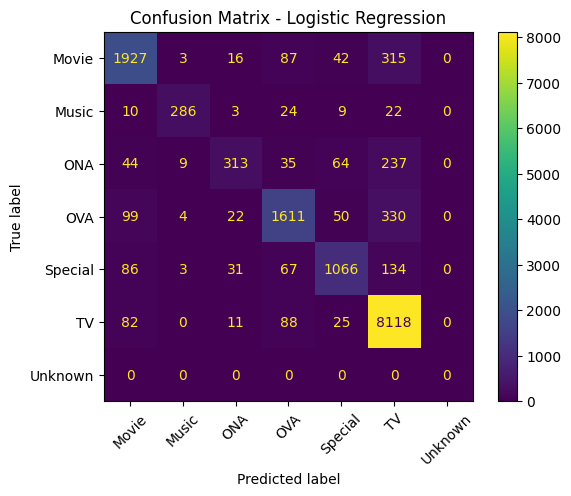

In [28]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()